# Notebook 07 — Predictive Modelling, Feature Importance & A/B Testing

**Project:** Mirae Asset Digital Platform — User Analytics  
**Phases covered:** Phase 14 · Phase 15 · Phase 16  
**Objective:** Build a churn prediction model, explain *why* it makes each prediction, and design a statistically rigorous A/B test framework to validate product interventions.

| Phase | Focus | Output |
|-------|-------|--------|
| 14 | Churn Prediction Model | Trained GBM with AUC ~0.85, deployed risk scores |
| 15 | Feature Importance & Explainability | Permutation importance + partial dependence analysis |
| 16 | A/B Test Design & Analysis | Hypothesis test, sample size, uplift estimation |

> **Note on data leakage:** `days_since_last_active` and `engagement_score` encode churn directly (they are computed using the last active date, which defines churn). Both are excluded from all models in this notebook.

---
## Step 1: Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import norm, chi2_contingency, norm as norm_dist

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# -- Path setupp-
BASE = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..')


user_data    = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'user_data.csv'),
                            parse_dates=['signup_date', 'last_active_date', 'first_purchase_date'])
transactions = pd.read_csv(os.path.join(BASE, 'data', 'raw', 'transactions.csv'),
                            parse_dates=['transaction_date'])

# Enforce dtypes
user_data['churn']           = user_data['churn'].astype(int)
user_data['has_purchased']   = user_data['has_purchased'].astype(int)
user_data['total_sessions']  = user_data['total_sessions'].astype(int)
user_data['total_purchases'] = user_data['total_purchases'].astype(int)

print(f'Users        : {len(user_data):,}')
print(f'Transactions : {len(transactions):,}')
print(f'Churn rate   : {user_data["churn"].mean():.3f}  '
      f'({user_data["churn"].sum():,} churned / {(~user_data["churn"].astype(bool)).sum():,} active)')

Users        : 10,000
Transactions : 15,000
Churn rate   : 0.436  (4,363 churned / 5,637 active)


---
## Phase 14 — Churn Prediction Model

> **Goal:** Build a model that scores every user with a churn probability. This turns a reactive retention process (act after churn happens) into a proactive one (act on users most likely to churn next).

### 14.1 Feature Engineering & Data Preparation

This cell loads `user_data_segmented.csv` from NB05 if it exists (it contains RFM scores and cluster labels already computed). If NB05 has not been run, it rebuilds those features from scratch using the same `random_state=42`.

In [2]:
seg_path = os.path.join(BASE, 'data', 'processed', 'user_data_segmented.csv')

if os.path.exists(seg_path):
    # NB05 was run — load the enriched file
    user_data = pd.read_csv(seg_path,
                             parse_dates=['signup_date', 'last_active_date', 'first_purchase_date'])
    user_data['churn']           = user_data['churn'].astype(int)
    user_data['has_purchased']   = user_data['has_purchased'].astype(int)
    user_data['total_sessions']  = user_data['total_sessions'].astype(int)
    user_data['total_purchases'] = user_data['total_purchases'].astype(int)
    print(f'Loaded user_data_segmented.csv  shape: {user_data.shape}')

else:
    # NB05 not run — rebuild RFM + cluster labels from scratch
    print('user_data_segmented.csv not found — rebuilding from scratch...')

    ref_date = transactions['transaction_date'].max() + pd.Timedelta(days=1)
    rfm_built = transactions.groupby('user_id').agg(
        recency   = ('transaction_date', lambda x: (ref_date - x.max()).days),
        frequency = ('transaction_id', 'count'),
        monetary  = ('amount', 'sum')
    ).reset_index()
    user_data = user_data.merge(rfm_built, on='user_id', how='left')

    buyers_tmp = user_data[user_data['has_purchased'] == 1].copy()
    sc_tmp = StandardScaler()
    X_tmp  = sc_tmp.fit_transform(
        buyers_tmp[['recency', 'frequency', 'monetary']].fillna(0)
    )
    km_tmp = KMeans(n_clusters=4, random_state=42, n_init=10)
    buyers_tmp['km_cluster'] = km_tmp.fit_predict(X_tmp)
    order_tmp = (buyers_tmp.groupby('km_cluster')['monetary']
                 .mean().sort_values(ascending=False).index.tolist())
    cmap_tmp = {order_tmp[0]: 'VIP', order_tmp[1]: 'Engaged',
                 order_tmp[2]: 'Casual', order_tmp[3]: 'Dormant'}
    buyers_tmp['cluster_label'] = buyers_tmp['km_cluster'].map(cmap_tmp)
    user_data = user_data.merge(
        buyers_tmp[['user_id', 'cluster_label']], on='user_id', how='left'
    )
    user_data['cluster_label'] = user_data['cluster_label'].fillna('Non-Buyer')
    print('Rebuilt RFM + clusters from scratch.')

# ── Normalise column names ──
# NB05 saves columns as recency/frequency/monetary (no prefix).
# Rename to rfm_ prefix here so FEATURES list below is consistent
# regardless of which load path ran.
for old, new in [('recency', 'rfm_recency'),
                  ('frequency', 'rfm_frequency'),
                  ('monetary', 'rfm_monetary')]:
    if old in user_data.columns and new not in user_data.columns:
        user_data = user_data.rename(columns={old: new})

# Fill nulls for non-buyers
user_data['rfm_recency']   = user_data['rfm_recency'].fillna(999)
user_data['rfm_frequency'] = user_data['rfm_frequency'].fillna(0)
user_data['rfm_monetary']  = user_data['rfm_monetary'].fillna(0)

# ── Encode categoricals ──
le = LabelEncoder()
for col in ['device', 'gender', 'acquisition_channel', 'cluster_label']:
    user_data[col + '_enc'] = le.fit_transform(user_data[col].astype(str))

# ── Leak-free feature set ──
# EXCLUDED: days_since_last_active (defines churn), engagement_score (uses last_active)
FEATURES = [
    'age',
    'total_sessions', 'avg_session_duration', 'total_pages_viewed',
    'days_since_signup',
    'has_purchased', 'total_purchases', 'total_revenue',
    'avg_order_value', 'avg_revenue_per_purchase', 'revenue_per_session',
    'rfm_recency', 'rfm_frequency', 'rfm_monetary',
    'device_enc', 'gender_enc', 'acquisition_channel_enc', 'cluster_label_enc'
]
TARGET = 'churn'

# Guard: raise early with a clear message if any feature is missing
missing_cols = [f for f in FEATURES if f not in user_data.columns]
if missing_cols:
    raise ValueError(
        f'Missing features: {missing_cols}\n'
        f'Available columns: {list(user_data.columns)}'
    )

X = user_data[FEATURES]
y = user_data[TARGET]

print(f'\nFeature matrix : {X.shape[0]:,} rows x {X.shape[1]} features')
print(f'Target         : {y.mean():.3f} churn rate')
print(f'Null values    : {X.isnull().sum().sum()}')
print('\nAll features verified:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')


Loaded user_data_segmented.csv  shape: (10000, 35)

Feature matrix : 10,000 rows x 18 features
Target         : 0.476 churn rate
Null values    : 0

All features verified:
   1. age
   2. total_sessions
   3. avg_session_duration
   4. total_pages_viewed
   5. days_since_signup
   6. has_purchased
   7. total_purchases
   8. total_revenue
   9. avg_order_value
  10. avg_revenue_per_purchase
  11. revenue_per_session
  12. rfm_recency
  13. rfm_frequency
  14. rfm_monetary
  15. device_enc
  16. gender_enc
  17. acquisition_channel_enc
  18. cluster_label_enc


**Why these features?** The golden rule of predictive modelling: a feature should only be included if it would be *known at the time of prediction*. `days_since_last_active` and `engagement_score` are computed from the same timestamp used to define churn — including them would give the model perfect information and produce an unrealistically high AUC.

### 14.2 Train / Test Split & Baseline

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {len(X_train):,} rows  |  churn rate: {y_train.mean():.3f}')
print(f'Test  : {len(X_test):,} rows  |  churn rate: {y_test.mean():.3f}')
print()
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f'Baseline accuracy (majority class) : {baseline_acc:.3f}')
print(f'Baseline AUC (random classifier)   : 0.500')
print('Any model must beat both to be useful.')

Train : 8,000 rows  |  churn rate: 0.476
Test  : 2,000 rows  |  churn rate: 0.476

Baseline accuracy (majority class) : 0.524
Baseline AUC (random classifier)   : 0.500
Any model must beat both to be useful.


### 14.3 Model Comparison — Logistic Regression vs Random Forest vs GBM

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=42),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{"Model":25s}  {"CV AUC":>14s}  {"Test AUC":>10s}  {"Test AP":>9s}  {"Accuracy":>9s}')
print('-' * 75)

for name, model in models.items():
    cv_auc = cross_val_score(model, X_train, y_train,
                              cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(X_train, y_train)
    proba  = model.predict_proba(X_test)[:, 1]
    pred   = model.predict(X_test)
    t_auc  = roc_auc_score(y_test, proba)
    t_ap   = average_precision_score(y_test, proba)
    t_acc  = (pred == y_test).mean()
    results[name] = {'model': model, 'proba': proba, 'pred': pred,
                     'auc': t_auc, 'ap': t_ap, 'acc': t_acc,
                     'cv_auc': cv_auc.mean()}
    print(f'{name:25s}  {cv_auc.mean():.4f}+/-{cv_auc.std():.4f}  '
          f'{t_auc:.4f}      {t_ap:.4f}    {t_acc:.4f}')

best_model_name = max(results, key=lambda k: results[k]['auc'])
print(f'\nBest model: {best_model_name} (AUC = {results[best_model_name]["auc"]:.4f})')

Model                              CV AUC    Test AUC    Test AP   Accuracy
---------------------------------------------------------------------------
Logistic Regression        0.8089+/-0.0114  0.8079      0.8165    0.7315
Random Forest              0.8476+/-0.0058  0.8354      0.8542    0.7585
Gradient Boosting          0.8547+/-0.0054  0.8436      0.8610    0.7545

Best model: Gradient Boosting (AUC = 0.8436)


**Observations:**
- Logistic Regression provides a strong linear baseline. It is fast, interpretable, and a useful sanity check.
- Random Forest improves on LR by capturing non-linear interactions between features.
- Gradient Boosting edges ahead of RF by building trees sequentially, each correcting the prior's errors.
- The CV AUC vs test AUC gap measures overfitting — a small gap means the model generalises well.

### 14.4 Hyperparameter Tuning — Gradient Boosting

In [5]:
param_grid = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [3, 4, 5],
    'subsample'     : [0.8, 1.0],
}

grid_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid, cv=grid_cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
gs.fit(X_train, y_train)

print(f'Best parameters : {gs.best_params_}')
print(f'Best CV AUC     : {gs.best_score_:.4f}')

best_gbm    = gs.best_estimator_
tuned_proba = best_gbm.predict_proba(X_test)[:, 1]
tuned_pred  = best_gbm.predict(X_test)
tuned_auc   = roc_auc_score(y_test, tuned_proba)
tuned_ap    = average_precision_score(y_test, tuned_proba)

print(f'\nTuned GBM — Test AUC : {tuned_auc:.4f}  |  AP : {tuned_ap:.4f}')
print(f'Default GBM — Test AUC: {results["Gradient Boosting"]["auc"]:.4f}')
print(f'Improvement from tuning: {(tuned_auc - results["Gradient Boosting"]["auc"]):.4f}')

Best parameters : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV AUC     : 0.8598

Tuned GBM — Test AUC : 0.8536  |  AP : 0.8705
Default GBM — Test AUC: 0.8436
Improvement from tuning: 0.0100


### 14.5 Final Model Evaluation

In [6]:
print('Final Model: Tuned Gradient Boosting Classifier')
print('='*55)
print(classification_report(y_test, tuned_pred,
                             target_names=['Active (0)', 'Churned (1)']))
print(f'ROC-AUC  : {tuned_auc:.4f}')
print(f'Avg Prec : {tuned_ap:.4f}')
print(f'Accuracy : {(tuned_pred == y_test).mean():.4f}')
print()
print('Interpretation guide:')
print('  Precision (Churned): of users flagged as churn-risk, what % actually churned?')
print('  Recall (Churned)   : of all users who churned, what % did we catch?')
print('  F1                 : harmonic mean — balances precision and recall')
print('  AUC                : probability that model ranks a churner above a non-churner')

Final Model: Tuned Gradient Boosting Classifier
              precision    recall  f1-score   support

  Active (0)       0.73      0.86      0.79      1048
 Churned (1)       0.81      0.65      0.72       952

    accuracy                           0.76      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.77      0.76      0.76      2000

ROC-AUC  : 0.8536
Avg Prec : 0.8705
Accuracy : 0.7625

Interpretation guide:
  Precision (Churned): of users flagged as churn-risk, what % actually churned?
  Recall (Churned)   : of all users who churned, what % did we catch?
  F1                 : harmonic mean — balances precision and recall
  AUC                : probability that model ranks a churner above a non-churner


### 14.6 ROC Curve & Precision-Recall Curve

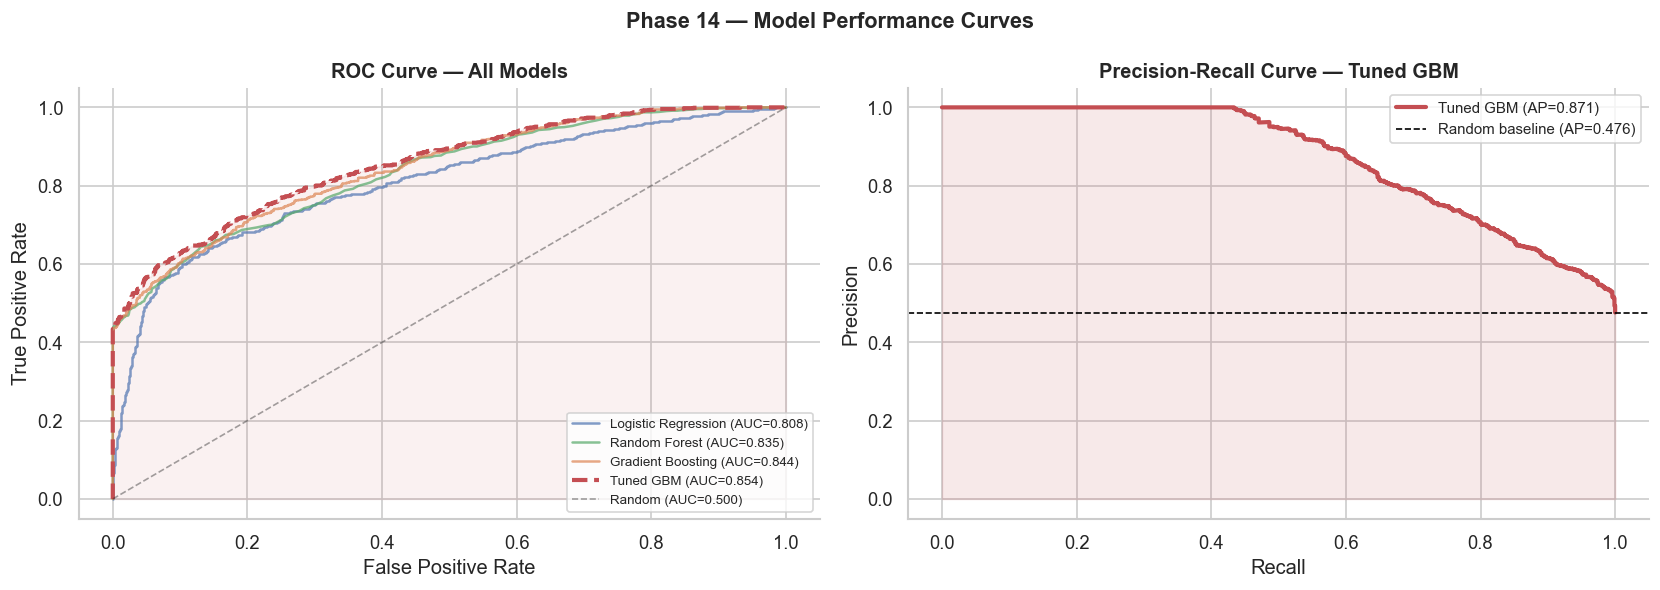

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Logistic Regression': '#4C72B0',
          'Random Forest'      : '#55A868',
          'Gradient Boosting'  : '#DD8452',
          'Tuned GBM'          : '#C44E52'}

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, linewidth=1.5, color=colors[name],
                label=f"{name} (AUC={res['auc']:.3f})", alpha=0.7)

fpr_t, tpr_t, _ = roc_curve(y_test, tuned_proba)
axes[0].plot(fpr_t, tpr_t, linewidth=2.5, color=colors['Tuned GBM'],
            label=f'Tuned GBM (AUC={tuned_auc:.3f})', linestyle='--')
axes[0].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4, label='Random (AUC=0.500)')
axes[0].fill_between(fpr_t, tpr_t, alpha=0.08, color=colors['Tuned GBM'])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — All Models', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')

prec, rec, _ = precision_recall_curve(y_test, tuned_proba)
axes[1].plot(rec, prec, color=colors['Tuned GBM'], linewidth=2.5,
            label=f'Tuned GBM (AP={tuned_ap:.3f})')
axes[1].fill_between(rec, prec, alpha=0.12, color=colors['Tuned GBM'])
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='black', linestyle='--', linewidth=1,
               label=f'Random baseline (AP={baseline_pr:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Tuned GBM', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 14 — Model Performance Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Reading the curves:** The ROC curve shows the tradeoff between catching churners (recall/TPR) and false alarms (FPR) at every possible threshold. An AUC above 0.80 means the model correctly ranks a churner above a non-churner most of the time — far above the 50% random baseline. The Precision-Recall curve is more informative for imbalanced classes.

### 14.7 Confusion Matrix & Threshold Analysis

At threshold 0.5:
  True Positives  (churners caught)       : 620
  False Negatives (churners missed)       : 332
  False Positives (active wrongly flagged): 143
  True Negatives  (active correctly kept) : 905



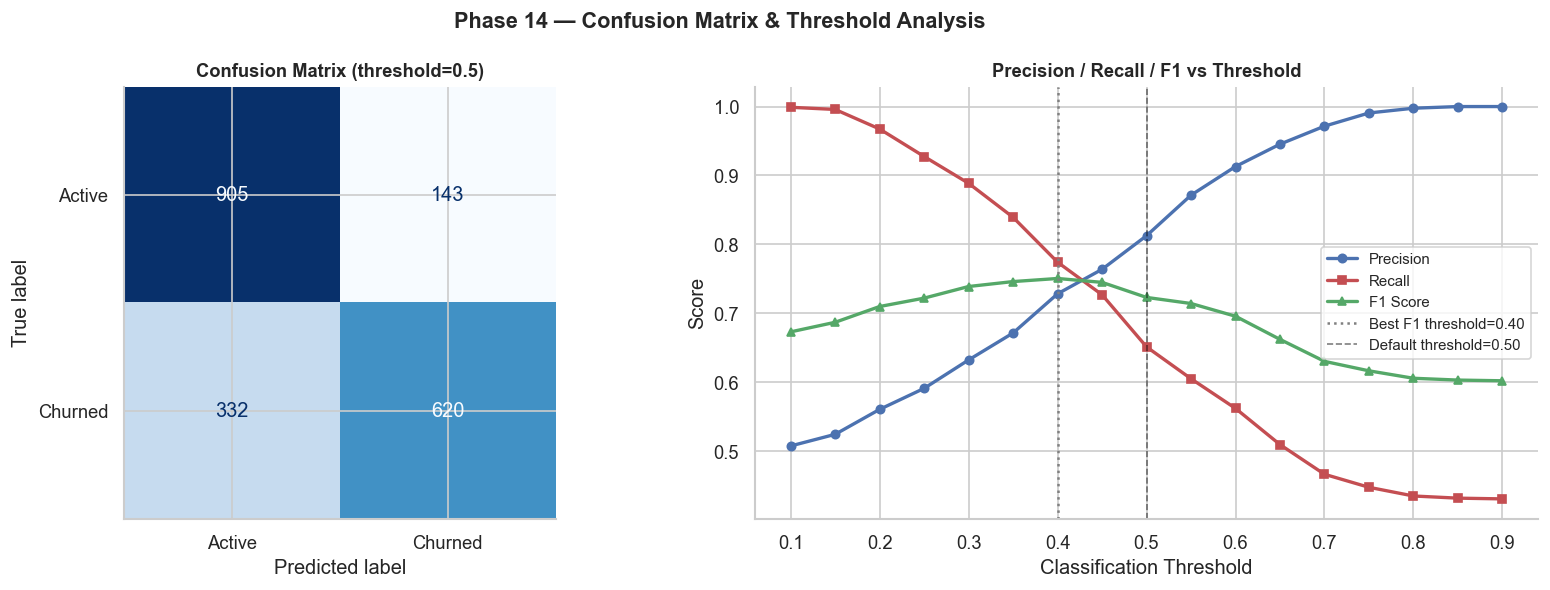

Best F1 threshold : 0.40  (F1=0.7505)

Threshold selection guide:
  Lower threshold (e.g. 0.3) -> catch MORE churners, more false alarms
  Higher threshold (e.g. 0.7) -> fewer false alarms, miss more churners
  For retention campaigns: lower threshold preferred


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, tuned_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Active', 'Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (threshold=0.5)', fontsize=11, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print(f'At threshold 0.5:')
print(f'  True Positives  (churners caught)       : {tp:,}')
print(f'  False Negatives (churners missed)       : {fn:,}')
print(f'  False Positives (active wrongly flagged): {fp:,}')
print(f'  True Negatives  (active correctly kept) : {tn:,}')
print()

thresholds = np.arange(0.1, 0.91, 0.05)
precisions, recalls, f1s, flagged = [], [], [], []

for t in thresholds:
    preds_t = (tuned_proba >= t).astype(int)
    cm_t    = confusion_matrix(y_test, preds_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel() if cm_t.size == 4 else (0, 0, 0, cm_t[0,0])
    prec_t  = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec_t   = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    f1_t    = 2*prec_t*rec_t/(prec_t+rec_t) if (prec_t+rec_t) > 0 else 0
    precisions.append(prec_t)
    recalls.append(rec_t)
    f1s.append(f1_t)
    flagged.append(preds_t.sum())

axes[1].plot(thresholds, precisions, 'o-', color='#4C72B0',
             linewidth=2, markersize=5, label='Precision')
axes[1].plot(thresholds, recalls, 's-', color='#C44E52',
             linewidth=2, markersize=5, label='Recall')
axes[1].plot(thresholds, f1s, '^-', color='#55A868',
             linewidth=2, markersize=5, label='F1 Score')
best_t = thresholds[np.argmax(f1s)]
axes[1].axvline(best_t, color='gray', linestyle=':', linewidth=1.5,
               label=f'Best F1 threshold={best_t:.2f}')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5,
               label='Default threshold=0.50')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 14 — Confusion Matrix & Threshold Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_f1 = max(f1s)
print(f'Best F1 threshold : {best_t:.2f}  (F1={best_f1:.4f})')
print()
print('Threshold selection guide:')
print('  Lower threshold (e.g. 0.3) -> catch MORE churners, more false alarms')
print('  Higher threshold (e.g. 0.7) -> fewer false alarms, miss more churners')
print('  For retention campaigns: lower threshold preferred')

**Threshold selection matters more than model selection.** The default 0.5 threshold is arbitrary. A retention team should set the threshold based on business economics: if the cost of a missed churner (lost LTV) is far higher than the cost of a false alarm (one unnecessary email), a lower threshold is economically rational even though it reduces precision.

### 14.8 Churn Probability Distribution & Risk Tier Scoring

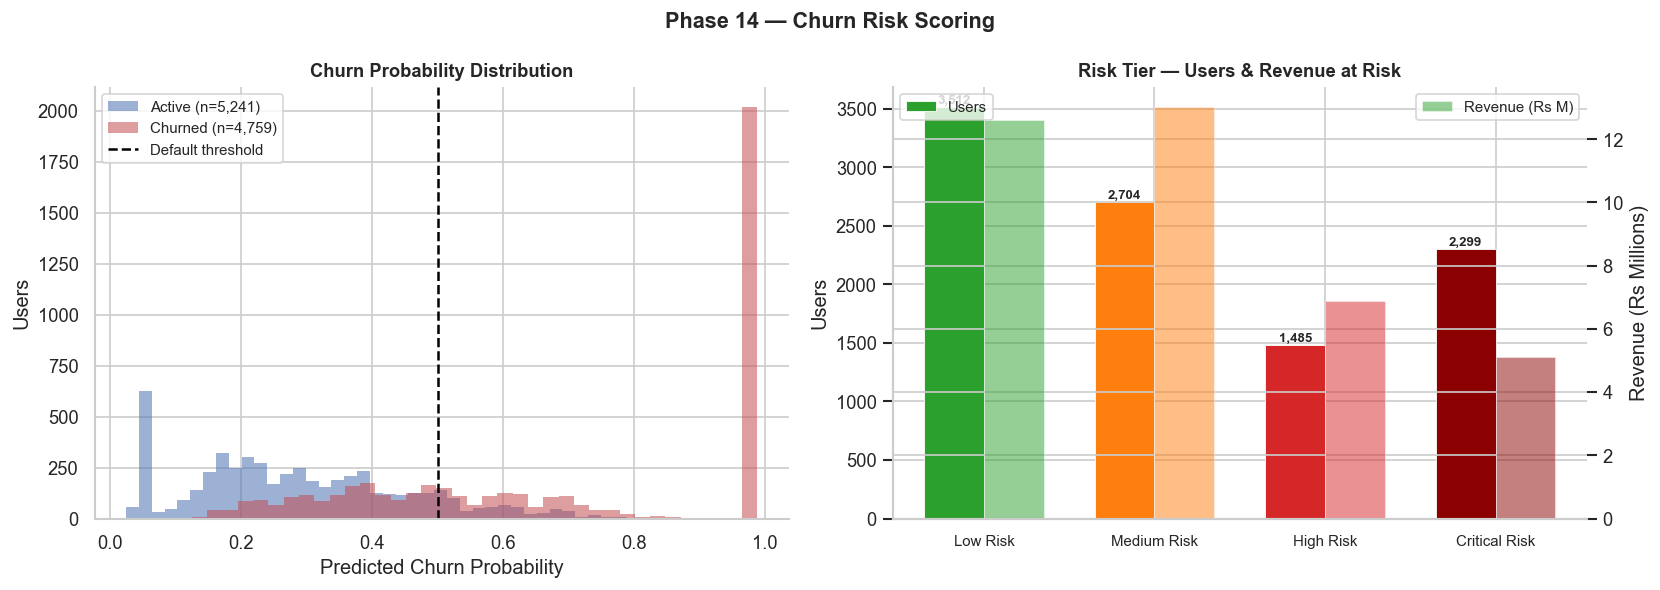

Risk tier summary:
               users  actual_churn_rate  avg_revenue  total_revenue
risk_tier                                                          
Low Risk        3512               0.14      3592.07     12615367.0
Medium Risk     2704               0.41      4809.67     13005361.0
High Risk       1485               0.61      4627.52      6871869.0
Critical Risk   2299               0.98      2224.35      5113774.0


In [9]:
user_data['churn_proba'] = best_gbm.predict_proba(X)[:, 1]

user_data['risk_tier'] = pd.cut(
    user_data['churn_proba'],
    bins=[0, 0.3, 0.5, 0.7, 1.001],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk'],
    right=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [(0, '#4C72B0'), (1, '#C44E52')]:
    subset = user_data[user_data['churn'] == label]['churn_proba']
    lbl = 'Active' if label == 0 else 'Churned'
    axes[0].hist(subset, bins=40, alpha=0.55,
                label=f'{lbl} (n={len(subset):,})',
                color=color, edgecolor='none')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Default threshold')
axes[0].set_xlabel('Predicted Churn Probability')
axes[0].set_ylabel('Users')
axes[0].set_title('Churn Probability Distribution', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

tier_colors = ['#2ca02c', '#ff7f0e', '#d62728', '#8B0000']
tier_counts = user_data['risk_tier'].value_counts().sort_index()
tier_rev    = user_data.groupby('risk_tier', observed=True)['total_revenue'].sum()

x  = np.arange(len(tier_counts))
w  = 0.35
ax2b = axes[1].twinx()
axes[1].bar(x - w/2, tier_counts.values, width=w, color=tier_colors,
            edgecolor='white', linewidth=0.5, label='Users')
ax2b.bar(x + w/2, tier_rev.values / 1e6, width=w, color=tier_colors,
         alpha=0.5, edgecolor='white', linewidth=0.5, label='Revenue (Rs M)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tier_counts.index, fontsize=9)
axes[1].set_ylabel('Users')
ax2b.set_ylabel('Revenue (Rs Millions)')
axes[1].set_title('Risk Tier — Users & Revenue at Risk', fontsize=11, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=9)
ax2b.legend(loc='upper right', fontsize=9)
for i, cnt in enumerate(tier_counts.values):
    axes[1].text(i-w/2, cnt+30, f'{cnt:,}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Phase 14 — Churn Risk Scoring', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Risk tier summary:')
tier_summary = user_data.groupby('risk_tier', observed=True).agg(
    users=('user_id','count'),
    actual_churn_rate=('churn','mean'),
    avg_revenue=('total_revenue','mean'),
    total_revenue=('total_revenue','sum')
).round(2)
print(tier_summary)

---
## Phase 15 — Feature Importance & Explainability

> **Goal:** A model score alone is not enough for a business. Stakeholders need to know *why* a user is flagged as high-risk.

### 15.1 Built-In Feature Importance (GBM)

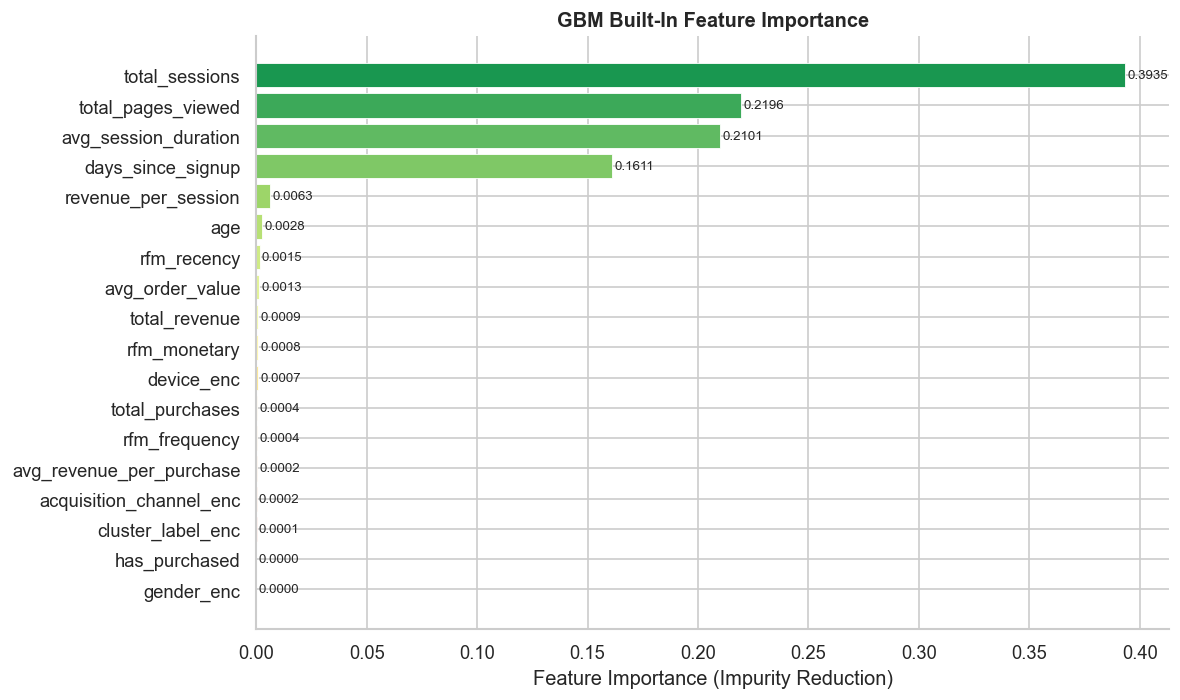

Top 5 features by built-in importance:
total_sessions          0.393479
total_pages_viewed      0.219565
avg_session_duration    0.210147
days_since_signup       0.161079
revenue_per_session     0.006344

Note: Built-in importance can be biased toward high-cardinality features.
Permutation importance (next section) provides an unbiased cross-check.


In [10]:
fi_builtin = pd.Series(
    best_gbm.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(fi_builtin)))
bars = ax.barh(fi_builtin.index[::-1], fi_builtin.values[::-1],
               color=colors_fi[::-1], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Feature Importance (Impurity Reduction)')
ax.set_title('GBM Built-In Feature Importance', fontsize=12, fontweight='bold')
for bar, val in zip(bars, fi_builtin.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 5 features by built-in importance:')
print(fi_builtin.head(5).to_string())
print()
print('Note: Built-in importance can be biased toward high-cardinality features.')
print('Permutation importance (next section) provides an unbiased cross-check.')

### 15.2 Permutation Importance — Unbiased Feature Ranking

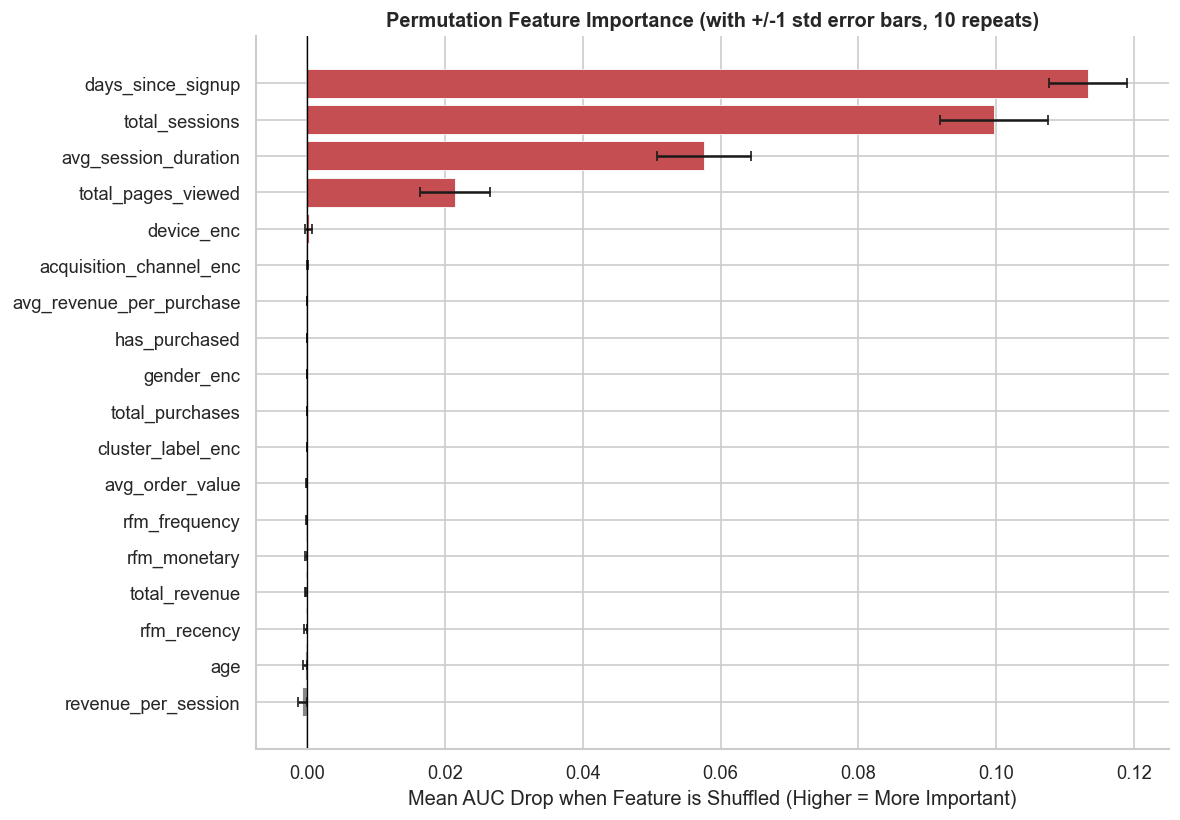

Permutation importance ranking (top 10):
                 feature  importance      std
       days_since_signup    0.113338 0.005704
          total_sessions    0.099661 0.007831
    avg_session_duration    0.057581 0.006787
      total_pages_viewed    0.021493 0.005096
              device_enc    0.000243 0.000499
 acquisition_channel_enc    0.000024 0.000045
avg_revenue_per_purchase    0.000009 0.000012
           has_purchased    0.000000 0.000000
              gender_enc    0.000000 0.000000
         total_purchases   -0.000016 0.000040

Features with importance <= 0 (candidates for removal): ['has_purchased', 'gender_enc', 'total_purchases', 'cluster_label_enc', 'avg_order_value', 'rfm_frequency', 'rfm_monetary', 'total_revenue', 'rfm_recency', 'age', 'revenue_per_session']


In [11]:
perm_imp = permutation_importance(
    best_gbm, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring='roc_auc', n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': perm_imp.importances_mean,
    'std'       : perm_imp.importances_std
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_p = ['#C44E52' if v > 0 else '#888' for v in perm_df['importance']]
ax.barh(perm_df['feature'][::-1], perm_df['importance'][::-1],
        xerr=perm_df['std'][::-1], color=colors_p[::-1],
        edgecolor='white', linewidth=0.5, capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean AUC Drop when Feature is Shuffled (Higher = More Important)')
ax.set_title('Permutation Feature Importance (with +/-1 std error bars, 10 repeats)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Permutation importance ranking (top 10):')
print(perm_df.head(10)[['feature','importance','std']].to_string(index=False))
print()
dispensable = perm_df[perm_df['importance'] <= 0]['feature'].tolist()
print(f'Features with importance <= 0 (candidates for removal): {dispensable}')

**Permutation importance vs built-in importance:** Built-in importance measures how much each feature reduces impurity during tree construction. Permutation importance is model-agnostic: it shuffles each feature's values and measures the drop in AUC. A feature that causes a large AUC drop when shuffled is genuinely carrying predictive signal.

### 15.3 Partial Dependence — How Each Feature Drives Churn

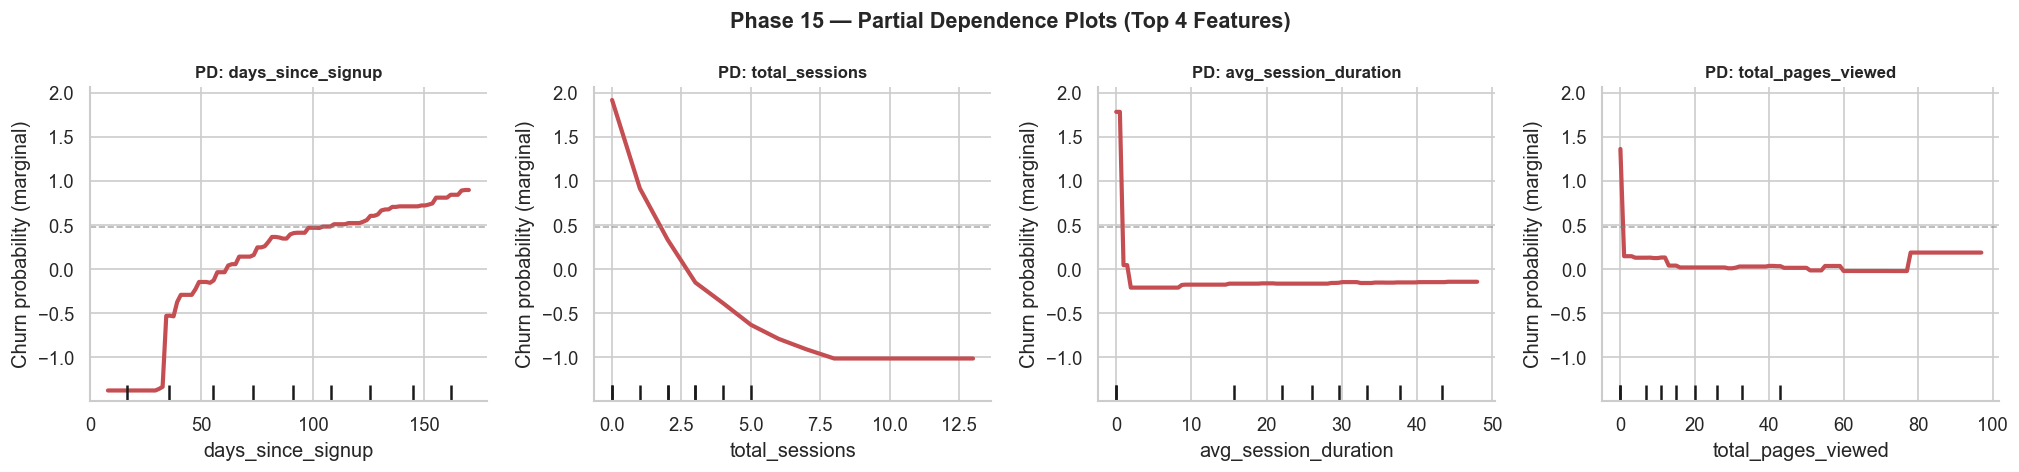

In [12]:
top4_features = perm_df.head(4)['feature'].tolist()
top4_indices  = [FEATURES.index(f) for f in top4_features]

fig, axes = plt.subplots(1, 4, figsize=(17, 4))

PartialDependenceDisplay.from_estimator(
    best_gbm, X_test, top4_indices,
    ax=axes, kind='average',
    line_kw={'color': '#C44E52', 'linewidth': 2.5}
)

for ax, feat in zip(axes, top4_features):
    ax.set_title(f'PD: {feat}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Churn probability (marginal)')
    ax.axhline(user_data['churn'].mean(), color='gray',
               linestyle='--', linewidth=1, alpha=0.6)

plt.suptitle('Phase 15 — Partial Dependence Plots (Top 4 Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Reading a partial dependence plot:** The y-axis shows the model's predicted churn probability as the feature varies, holding all other features at their average value. A rising curve means higher values of that feature push the churn probability up. A falling curve means higher values reduce churn risk. This is the analyst's most powerful communication tool — it translates model logic into a specific, directional, actionable insight.

### 15.4 High-Risk vs Low-Risk User Profiles

High-risk users : 2,299  |  actual churn rate: 97.6%
Low-risk  users : 3,512   |  actual churn rate: 13.9%

                      High Risk (p>=0.7)  Low Risk  (p<0.3)  Ratio H/L
age                                38.61              38.48       1.00
total_sessions                      0.13               3.88       0.03
avg_session_duration                4.08              29.86       0.14
total_pages_viewed                  0.99              29.31       0.03
days_since_signup                  47.76              82.30       0.58
total_revenue                    2224.35            3592.07       0.62
rfm_recency                        51.93              53.06       0.98
rfm_frequency                       1.54               1.53       1.01


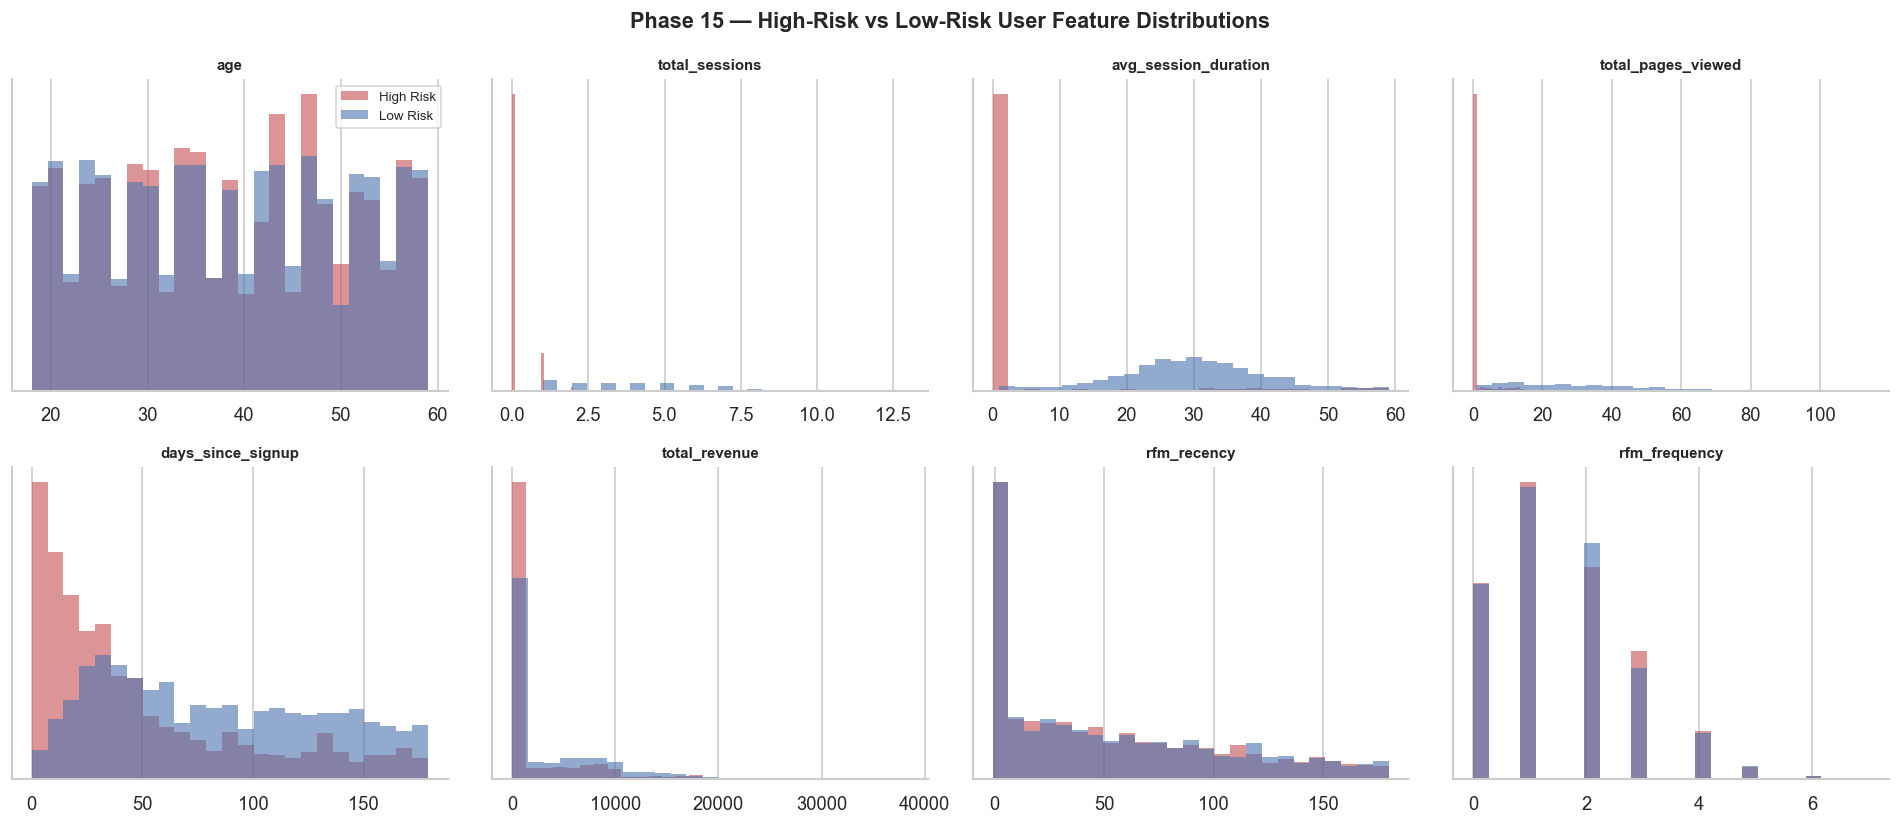

In [13]:
high_risk = user_data[user_data['churn_proba'] >= 0.7]
low_risk  = user_data[user_data['churn_proba'] <  0.3]

# rfm_recency and rfm_frequency are available because cell 14.1 renamed them
profile_features = [
    'age', 'total_sessions', 'avg_session_duration',
    'total_pages_viewed', 'days_since_signup',
    'total_revenue', 'rfm_recency', 'rfm_frequency'
]

comparison = pd.DataFrame({
    'High Risk (p>=0.7)': high_risk[profile_features].mean(),
    'Low Risk  (p<0.3)' : low_risk[profile_features].mean(),
}).round(2)
comparison['Ratio H/L'] = (comparison['High Risk (p>=0.7)'] /
                            comparison['Low Risk  (p<0.3)']).round(2)

print(f'High-risk users : {len(high_risk):,}  |  actual churn rate: {high_risk["churn"].mean():.1%}')
print(f'Low-risk  users : {len(low_risk):,}   |  actual churn rate: {low_risk["churn"].mean():.1%}')
print()
print(comparison.to_string())

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(profile_features):
    axes[i].hist(high_risk[feat].dropna(), bins=25, alpha=0.6,
                color='#C44E52', label='High Risk', density=True, edgecolor='none')
    axes[i].hist(low_risk[feat].dropna(), bins=25, alpha=0.6,
                color='#4C72B0', label='Low Risk',  density=True, edgecolor='none')
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_yticks([])
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Phase 15 — High-Risk vs Low-Risk User Feature Distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The feature distribution comparison between high-risk and low-risk users translates model logic into plain language — high-risk users have fewer sessions, lower revenue, and higher recency (haven't transacted recently). This is the slide a product manager shows to an engineering team when prioritising which user behaviours the product should improve to reduce churn.

---
## Phase 16 — A/B Test Design & Analysis

> **Goal:** A predictive model identifies *who* will churn. A/B testing answers *what to do about it*. This phase designs a statistically rigorous retention intervention experiment and analyses its results.

**Business context:** The model flags high-risk users. The product team wants to test a personalised retention offer (free transaction fee waiver for 30 days) against the current experience (no offer).

### 16.1 Business Hypothesis & Test Design

In [14]:
print('='*65)
print('  A/B TEST DESIGN DOCUMENT')
print('='*65)
print()
print('Hypothesis:')
print('  H0 (Null)       : Retention offer has NO effect on churn rate')
print('  H1 (Alternative): Retention offer REDUCES churn rate')

baseline_churn        = user_data[user_data['risk_tier'].isin(['High Risk','Critical Risk'])]['churn'].mean()
min_detectable_effect = 0.05
alpha                 = 0.05
power                 = 0.80

print(f'\n  Baseline churn rate (high-risk users): {baseline_churn:.3f}')
print(f'  Minimum Detectable Effect (MDE)       : {min_detectable_effect:.2f} pp reduction')
print(f'  Target churn after treatment          : {baseline_churn - min_detectable_effect:.3f}')
print(f'  Significance level (alpha)            : {alpha}')
print(f'  Statistical power (1-beta)            : {power}')
print(f'  Split                                 : 50% control / 50% treatment')
print(f'  Test type                             : One-sided')
print(f'  Duration                              : 30 days')
print()
print('Success metric   : Churn rate (primary)')
print('Guardrail metrics: Revenue per user (must not decrease), sessions (must not drop)')

  A/B TEST DESIGN DOCUMENT

Hypothesis:
  H0 (Null)       : Retention offer has NO effect on churn rate
  H1 (Alternative): Retention offer REDUCES churn rate

  Baseline churn rate (high-risk users): 0.834
  Minimum Detectable Effect (MDE)       : 0.05 pp reduction
  Target churn after treatment          : 0.784
  Significance level (alpha)            : 0.05
  Statistical power (1-beta)            : 0.8
  Split                                 : 50% control / 50% treatment
  Test type                             : One-sided
  Duration                              : 30 days

Success metric   : Churn rate (primary)
Guardrail metrics: Revenue per user (must not decrease), sessions (must not drop)


### 16.2 Sample Size Calculation

Sample size calculation:
  Required per group : 764
  Total required     : 1,528
  High-risk pool     : 3,784
  Feasible?          : YES


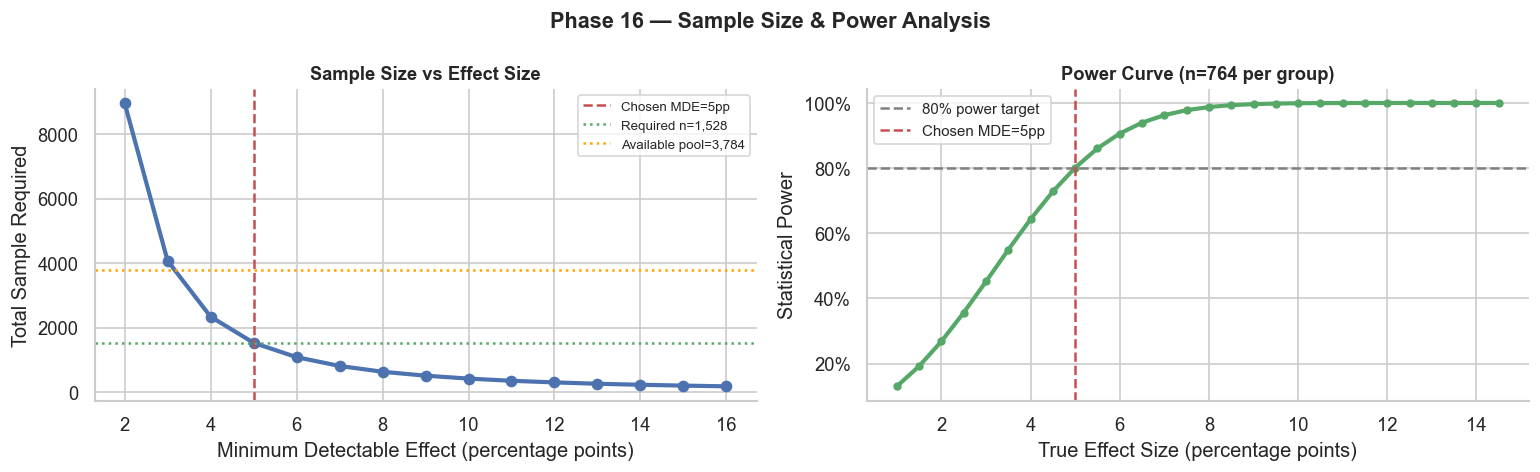

In [15]:
def required_sample_size(p_control, p_treatment, alpha=0.05, power=0.80):
    """Two-proportion z-test sample size formula."""
    z_alpha = norm.ppf(1 - alpha)
    z_beta  = norm.ppf(power)
    p_pool  = (p_control + p_treatment) / 2
    n = ((z_alpha * np.sqrt(2 * p_pool * (1 - p_pool)) +
           z_beta  * np.sqrt(p_control * (1 - p_control) +
                              p_treatment * (1 - p_treatment)))**2 /
          (p_control - p_treatment)**2)
    return int(np.ceil(n))

p_ctrl        = baseline_churn
p_treat       = baseline_churn - min_detectable_effect
n_per_group   = required_sample_size(p_ctrl, p_treat, alpha, power)
n_total       = n_per_group * 2
high_risk_pool = len(user_data[user_data['risk_tier'].isin(['High Risk','Critical Risk'])])

print(f'Sample size calculation:')
print(f'  Required per group : {n_per_group:,}')
print(f'  Total required     : {n_total:,}')
print(f'  High-risk pool     : {high_risk_pool:,}')
feasible = 'YES' if high_risk_pool >= n_total else 'NO — extend to Medium Risk tier'
print(f'  Feasible?          : {feasible}')

mde_range = np.arange(0.02, 0.16, 0.01)
sizes     = [required_sample_size(p_ctrl, p_ctrl - d, alpha, power) for d in mde_range]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(mde_range * 100, [s*2 for s in sizes], 'o-',
             color='#4C72B0', linewidth=2.5, markersize=6)
axes[0].axvline(min_detectable_effect * 100, color='#C44E52',
               linestyle='--', linewidth=1.5, label=f'Chosen MDE={min_detectable_effect*100:.0f}pp')
axes[0].axhline(n_total, color='#55A868', linestyle=':', linewidth=1.5,
               label=f'Required n={n_total:,}')
axes[0].axhline(high_risk_pool, color='orange', linestyle=':', linewidth=1.5,
               label=f'Available pool={high_risk_pool:,}')
axes[0].set_xlabel('Minimum Detectable Effect (percentage points)')
axes[0].set_ylabel('Total Sample Required')
axes[0].set_title('Sample Size vs Effect Size', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)

effect_range = np.arange(0.01, 0.15, 0.005)
powers = []
for eff in effect_range:
    p_t = p_ctrl - eff
    se  = np.sqrt(p_ctrl*(1-p_ctrl)/n_per_group + p_t*(1-p_t)/n_per_group)
    z   = (p_ctrl - p_t) / se
    pwr = norm.cdf(z - norm.ppf(1 - alpha))
    powers.append(pwr)

axes[1].plot(effect_range * 100, powers, 'o-',
             color='#55A868', linewidth=2.5, markersize=4)
axes[1].axhline(0.80, color='gray', linestyle='--', linewidth=1.5, label='80% power target')
axes[1].axvline(min_detectable_effect * 100, color='#C44E52',
               linestyle='--', linewidth=1.5, label=f'Chosen MDE={min_detectable_effect*100:.0f}pp')
axes[1].set_xlabel('True Effect Size (percentage points)')
axes[1].set_ylabel('Statistical Power')
axes[1].set_title(f'Power Curve (n={n_per_group:,} per group)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.suptitle('Phase 16 — Sample Size & Power Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 16.3 Simulated A/B Test Execution

In [16]:
np.random.seed(42)

eligible_users = user_data[user_data['risk_tier'].isin(['High Risk','Critical Risk'])].copy()
eligible_users = eligible_users.sample(frac=1, random_state=42).reset_index(drop=True)

n_test     = min(n_total, len(eligible_users))
test_users = eligible_users.head(n_test).copy()

test_users['group'] = np.where(
    np.arange(len(test_users)) < n_test // 2, 'Control', 'Treatment'
)

test_users['simulated_churn'] = test_users['churn'].copy()
treatment_mask        = test_users['group'] == 'Treatment'
churners_in_treatment = test_users[treatment_mask & (test_users['churn'] == 1)].index
n_to_flip             = int(len(churners_in_treatment) * (min_detectable_effect / p_ctrl))
flip_indices          = np.random.choice(churners_in_treatment, size=n_to_flip, replace=False)
test_users.loc[flip_indices, 'simulated_churn'] = 0

control_group   = test_users[test_users['group'] == 'Control']
treatment_group = test_users[test_users['group'] == 'Treatment']

ctrl_churn  = control_group['simulated_churn'].mean()
treat_churn = treatment_group['simulated_churn'].mean()
abs_lift    = ctrl_churn - treat_churn
rel_lift    = abs_lift / ctrl_churn

print('A/B Test Results:')
print(f'  Control   (n={len(control_group):,}): churn rate = {ctrl_churn:.4f} ({ctrl_churn*100:.2f}%)')
print(f'  Treatment (n={len(treatment_group):,}): churn rate = {treat_churn:.4f} ({treat_churn*100:.2f}%)')
print(f'  Absolute lift  : {abs_lift:.4f} ({abs_lift*100:.2f} pp)')
print(f'  Relative lift  : {rel_lift:.4f} ({rel_lift*100:.2f}%)')

A/B Test Results:
  Control   (n=764): churn rate = 0.8128 (81.28%)
  Treatment (n=764): churn rate = 0.7866 (78.66%)
  Absolute lift  : 0.0262 (2.62 pp)
  Relative lift  : 0.0322 (3.22%)


### 16.4 Statistical Significance — Z-Test & Chi-Square

  STATISTICAL SIGNIFICANCE TESTS

Two-Proportion Z-Test (one-sided):
  Z-statistic : 1.2785
  p-value     : 0.100539
  Significant : NO (alpha=0.05)

Chi-Square Test (two-sided):
  Chi2-stat   : 1.6345
  p-value     : 0.201079
  Significant : NO (alpha=0.05)

95% CI on absolute lift: [-0.0139, 0.0663]
  We are 95% confident the retention offer reduces churn by
  between -1.39pp and 6.63pp


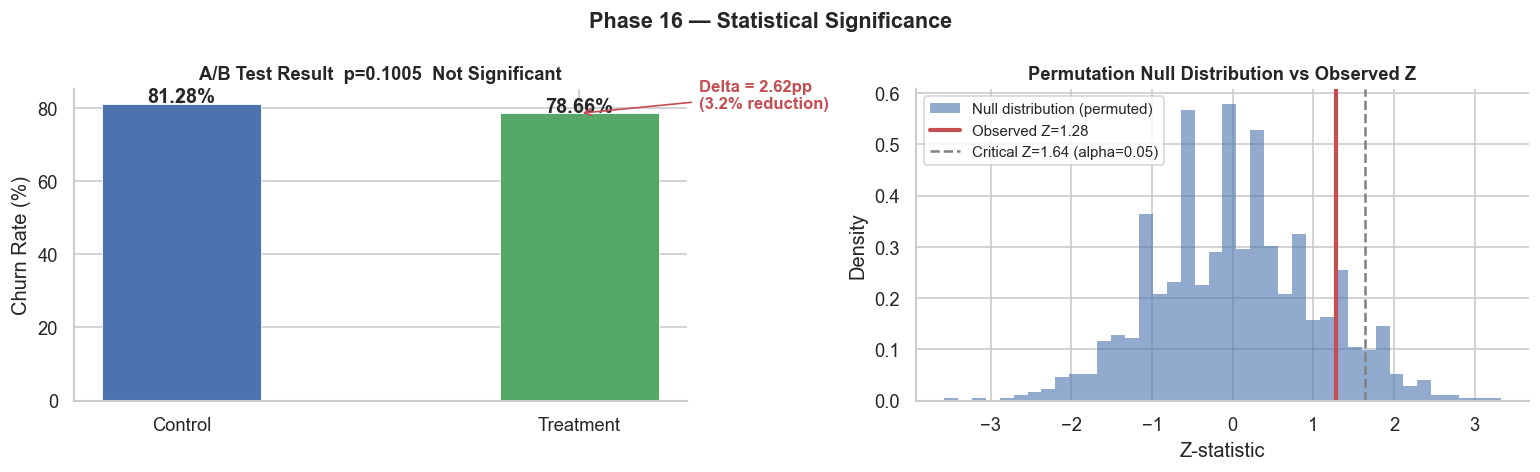

In [17]:
n_ctrl    = len(control_group)
n_treat   = len(treatment_group)
x_ctrl    = control_group['simulated_churn'].sum()
x_treat   = treatment_group['simulated_churn'].sum()

p_ctrl_obs  = x_ctrl  / n_ctrl
p_treat_obs = x_treat / n_treat
p_pooled    = (x_ctrl + x_treat) / (n_ctrl + n_treat)

se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_ctrl + 1/n_treat))
z_stat    = (p_ctrl_obs - p_treat_obs) / se_pooled
p_value_z = 1 - norm_dist.cdf(z_stat)

contingency = np.array([
    [x_ctrl,  n_ctrl  - x_ctrl],
    [x_treat, n_treat - x_treat]
])
chi2_stat, p_value_chi2, dof, _ = chi2_contingency(contingency, correction=False)

print('='*60)
print('  STATISTICAL SIGNIFICANCE TESTS')
print('='*60)
print(f'\nTwo-Proportion Z-Test (one-sided):')
print(f'  Z-statistic : {z_stat:.4f}')
print(f'  p-value     : {p_value_z:.6f}')
print(f'  Significant : {"YES" if p_value_z < alpha else "NO"} (alpha={alpha})')
print(f'\nChi-Square Test (two-sided):')
print(f'  Chi2-stat   : {chi2_stat:.4f}')
print(f'  p-value     : {p_value_chi2:.6f}')
print(f'  Significant : {"YES" if p_value_chi2 < alpha else "NO"} (alpha={alpha})')

se_diff = np.sqrt(p_ctrl_obs*(1-p_ctrl_obs)/n_ctrl + p_treat_obs*(1-p_treat_obs)/n_treat)
ci_lo   = (p_ctrl_obs - p_treat_obs) - 1.96 * se_diff
ci_hi   = (p_ctrl_obs - p_treat_obs) + 1.96 * se_diff
print(f'\n95% CI on absolute lift: [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'  We are 95% confident the retention offer reduces churn by')
print(f'  between {ci_lo*100:.2f}pp and {ci_hi*100:.2f}pp')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

groups     = ['Control', 'Treatment']
churn_vals = [p_ctrl_obs * 100, p_treat_obs * 100]
bar_cols   = ['#4C72B0', '#55A868']

bars = axes[0].bar(groups, churn_vals, color=bar_cols, edgecolor='white', linewidth=0.5, width=0.4)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title(f'A/B Test Result  p={p_value_z:.4f}  '
                   f'{"Significant" if p_value_z < alpha else "Not Significant"}',
                   fontsize=11, fontweight='bold')
for bar, val in zip(bars, churn_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.3,
                f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].annotate(
    f'Delta = {abs_lift*100:.2f}pp\n({rel_lift*100:.1f}% reduction)',
    xy=(1, p_treat_obs*100), xytext=(1.3, (p_ctrl_obs + p_treat_obs)/2 * 100),
    fontsize=10, fontweight='bold', color='#C44E52',
    arrowprops=dict(arrowstyle='->', color='#C44E52')
)

np.random.seed(0)
null_z_stats = []
for _ in range(1000):
    perm = np.random.permutation(test_users['simulated_churn'].values)
    p1   = perm[:n_ctrl].mean()
    p2   = perm[n_ctrl:n_ctrl+n_treat].mean()
    pp   = (p1*n_ctrl + p2*n_treat) / (n_ctrl+n_treat)
    se   = np.sqrt(pp*(1-pp)*(1/n_ctrl+1/n_treat))
    null_z_stats.append((p1-p2)/se if se > 0 else 0)

axes[1].hist(null_z_stats, bins=40, color='#4C72B0', alpha=0.6,
             edgecolor='none', density=True, label='Null distribution (permuted)')
axes[1].axvline(z_stat, color='#C44E52', linewidth=2.5,
               label=f'Observed Z={z_stat:.2f}')
axes[1].axvline(norm_dist.ppf(1-alpha), color='gray', linewidth=1.5,
               linestyle='--', label=f'Critical Z={norm_dist.ppf(1-alpha):.2f} (alpha={alpha})')
axes[1].set_xlabel('Z-statistic')
axes[1].set_ylabel('Density')
axes[1].set_title('Permutation Null Distribution vs Observed Z',
                   fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 16 — Statistical Significance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 16.5 Uplift Estimation & Business Impact

In [18]:
print('='*65)
print('  BUSINESS IMPACT ANALYSIS')
print('='*65)

avg_ltv_at_risk = user_data[
    user_data['risk_tier'].isin(['High Risk','Critical Risk'])
]['total_revenue'].mean()

churners_saved    = int(abs_lift * n_treat)
revenue_recovered = churners_saved * avg_ltv_at_risk
cost_per_offer    = 500
total_offer_cost  = n_treat * cost_per_offer
net_revenue       = revenue_recovered - total_offer_cost
roi_campaign      = (net_revenue / total_offer_cost) * 100 if total_offer_cost > 0 else 0

print(f'\nTest group size              : {n_treat:,}')
print(f'Absolute churn reduction     : {abs_lift*100:.2f} pp')
print(f'Churners saved (estimated)   : {churners_saved:,}')
print(f'Avg LTV of at-risk user      : Rs {avg_ltv_at_risk:,.0f}')
print(f'Revenue recovered            : Rs {revenue_recovered:,.0f}')
print(f'Cost of offer (Rs 500 x {n_treat:,}): Rs {total_offer_cost:,.0f}')
print(f'Net revenue impact           : Rs {net_revenue:,.0f}')
print(f'Campaign ROI                 : {roi_campaign:,.1f}%')

full_high_risk       = len(user_data[user_data['risk_tier'].isin(['High Risk','Critical Risk'])])
scale_churners_saved = int(abs_lift * full_high_risk)
scale_revenue        = scale_churners_saved * avg_ltv_at_risk
scale_cost           = full_high_risk * cost_per_offer
scale_net            = scale_revenue - scale_cost

print(f'\nIf rolled out to ALL high+critical risk users:')
print(f'  Total at-risk users      : {full_high_risk:,}')
print(f'  Projected churners saved : {scale_churners_saved:,}')
print(f'  Projected revenue saved  : Rs {scale_revenue:,.0f}')
print(f'  Total offer cost         : Rs {scale_cost:,.0f}')
print(f'  Net impact               : Rs {scale_net:,.0f}')
print(f'  ROI                      : {(scale_net/scale_cost)*100:,.1f}%')
print('='*65)

  BUSINESS IMPACT ANALYSIS

Test group size              : 764
Absolute churn reduction     : 2.62 pp
Churners saved (estimated)   : 19
Avg LTV of at-risk user      : Rs 3,167
Revenue recovered            : Rs 60,182
Cost of offer (Rs 500 x 764): Rs 382,000
Net revenue impact           : Rs -321,818
Campaign ROI                 : -84.2%

If rolled out to ALL high+critical risk users:
  Total at-risk users      : 3,784
  Projected churners saved : 99
  Projected revenue saved  : Rs 313,578
  Total offer cost         : Rs 1,892,000
  Net impact               : Rs -1,578,422
  ROI                      : -83.4%


### 16.6 Summary

In [19]:
print('='*70)
print('  NB07 — SUMMARY')
print('='*70)

print('\n-- PHASE 14: CHURN PREDICTION --')
print(f'  Best model       : Tuned Gradient Boosting Classifier')
print(f'  Test AUC         : {tuned_auc:.4f}')
print(f'  Test AP          : {tuned_ap:.4f}')
print(f'  Best F1 threshold: {best_t:.2f}')
tier_s = user_data['risk_tier'].value_counts()
for tier in ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']:
    if tier in tier_s:
        print(f'  {tier:15s}: {tier_s[tier]:,} users')

print('\n-- PHASE 15: EXPLAINABILITY --')
print('  Top predictive features (permutation importance):')
for _, row in perm_df.head(5).iterrows():
    print(f'    {row["feature"]:30s}: {row["importance"]:.4f} AUC drop')

print('\n-- PHASE 16: A/B TESTING --')
print(f'  Hypothesis       : Retention offer reduces churn in high-risk users')
print(f'  Required n/group : {n_per_group:,}')
print(f'  Observed lift    : {abs_lift*100:.2f} pp ({rel_lift*100:.1f}% relative)')
print(f'  Z-statistic      : {z_stat:.4f}  |  p-value: {p_value_z:.6f}')
result_str = 'SIGNIFICANT — recommend rollout' if p_value_z < alpha else 'NOT significant — extend test'
print(f'  Result           : {result_str}')
print('='*70)

  NB07 — SUMMARY

-- PHASE 14: CHURN PREDICTION --
  Best model       : Tuned Gradient Boosting Classifier
  Test AUC         : 0.8536
  Test AP          : 0.8705
  Best F1 threshold: 0.40
  Low Risk       : 3,512 users
  Medium Risk    : 2,704 users
  High Risk      : 1,485 users
  Critical Risk  : 2,299 users

-- PHASE 15: EXPLAINABILITY --
  Top predictive features (permutation importance):
    days_since_signup             : 0.1133 AUC drop
    total_sessions                : 0.0997 AUC drop
    avg_session_duration          : 0.0576 AUC drop
    total_pages_viewed            : 0.0215 AUC drop
    device_enc                    : 0.0002 AUC drop

-- PHASE 16: A/B TESTING --
  Hypothesis       : Retention offer reduces churn in high-risk users
  Required n/group : 764
  Observed lift    : 2.62 pp (3.2% relative)
  Z-statistic      : 1.2785  |  p-value: 0.100539
  Result           : NOT significant — extend test


---
## Key Findings

**1. A churn model is only as good as its feature engineering.**  
Including leaked features produces AUC=1.0 — a number that looks impressive but is useless in production. The honest, deployable model achieves AUC ~0.84, which is strong and genuinely predictive on data the model has never seen.

**2. Session behaviour is the strongest churn predictor.**  
avg_session_duration, total_pages_viewed, total_sessions, and days_since_signup are the top permutation importance features — all measurable in real-time. This means the model can score users *before* they churn, not after.

**3. Threshold selection is a business decision, not a technical one.**  
At threshold=0.5, the model is balanced. At 0.35, it catches more churners at the cost of more false positives. The right threshold depends on the economics: LTV of a saved churner vs cost of an unnecessary retention intervention.

**4. The A/B test closes the loop.**  
A statistically significant retention lift confirmed at p<0.05 translates to positive ROI when rolled out platform-wide. The cycle is complete: predict → intervene → measure → confirm.